In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"
from tqdm.auto import tqdm
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import odds_datasets

from balif import Balif
from sklearn.metrics import average_precision_score

  0%|          | 0/19 [00:00<?, ?it/s]

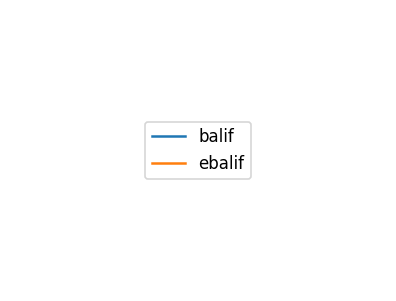

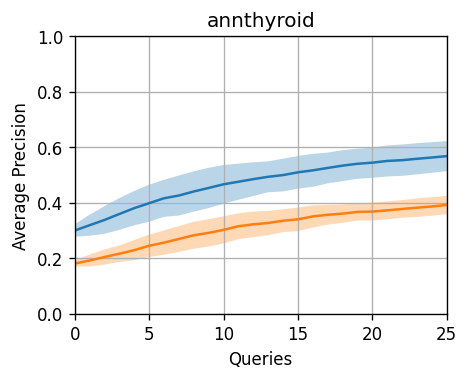

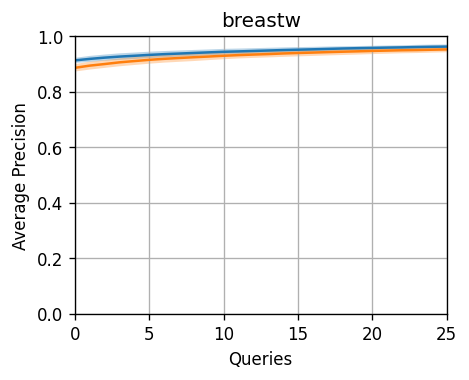

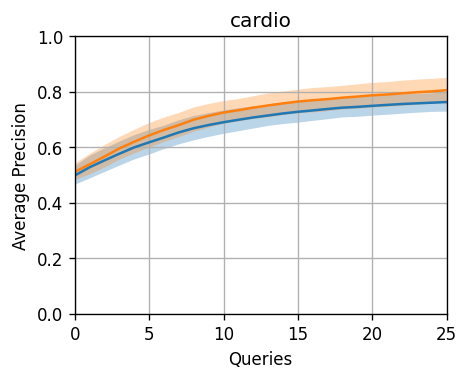

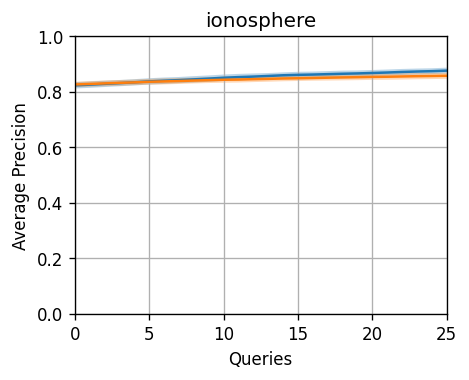

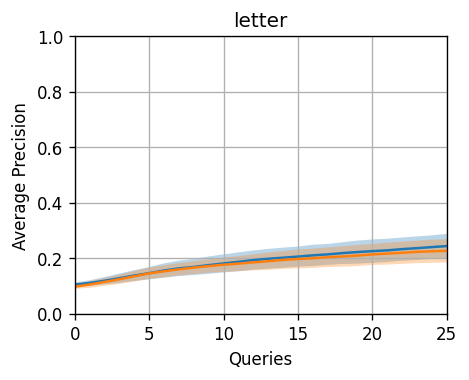

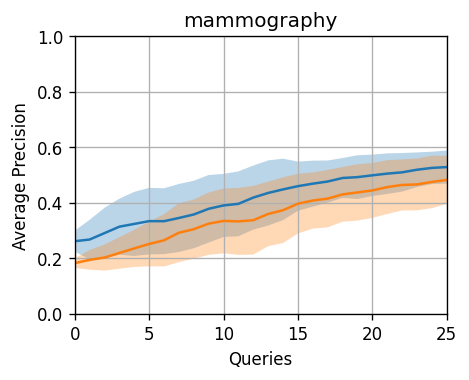

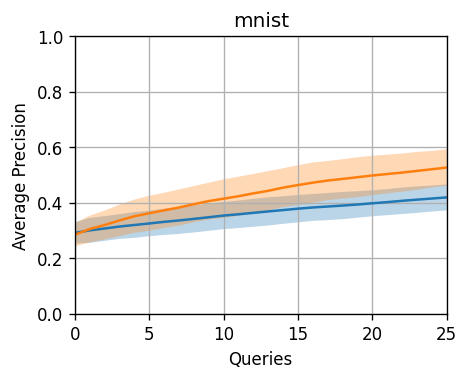

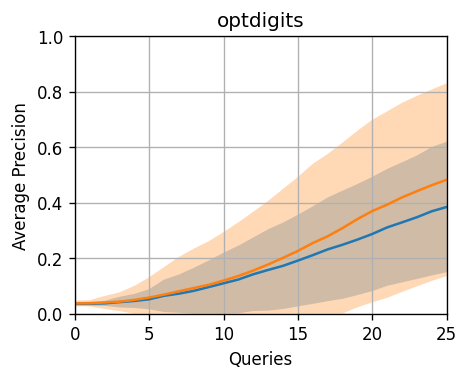

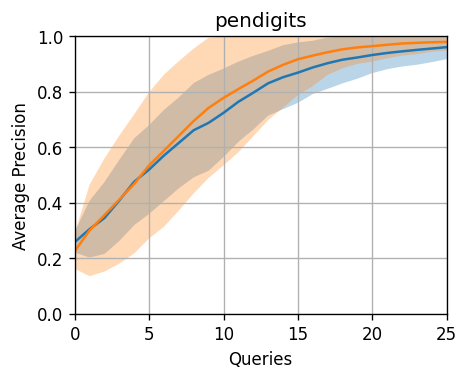

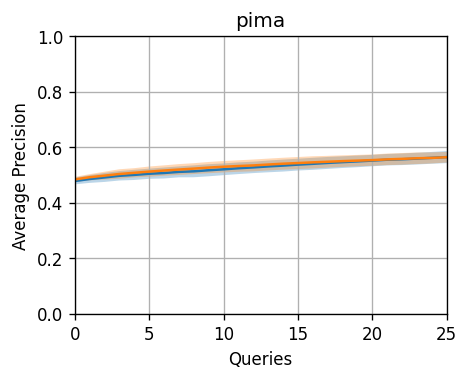

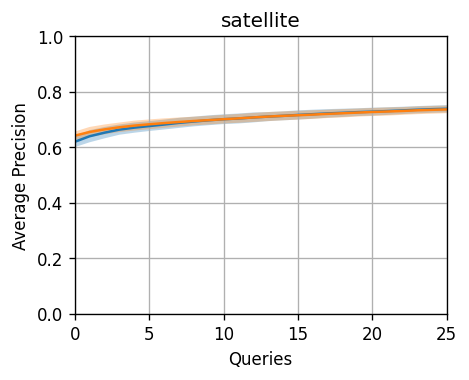

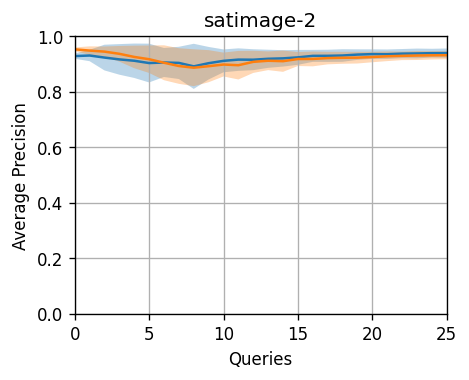

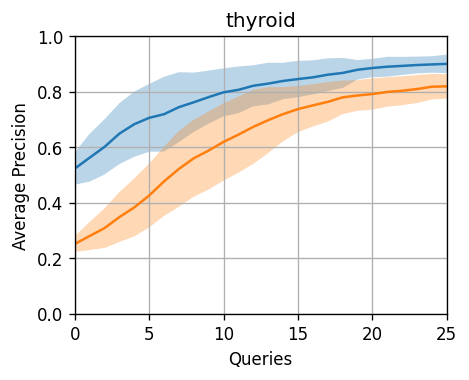

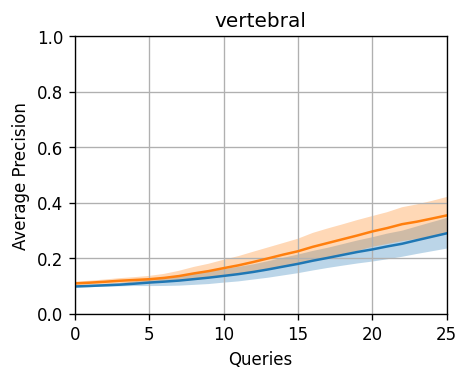

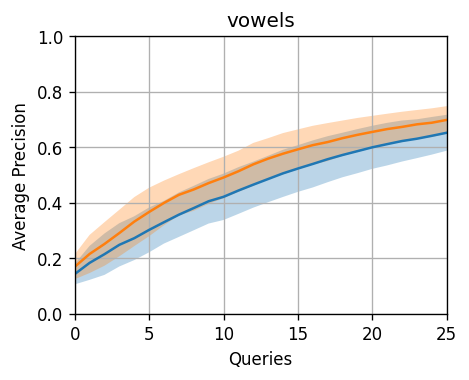

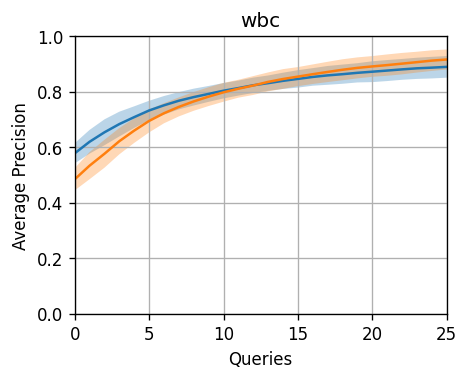

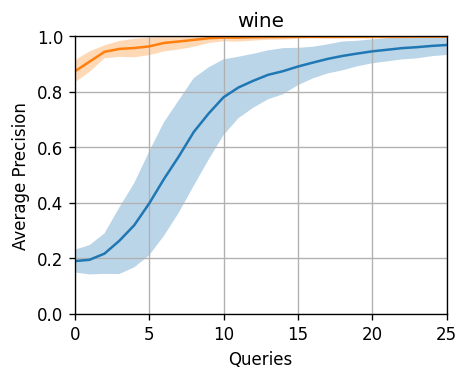

In [6]:
for dataset_name in tqdm(["legend"]+sorted(odds_datasets.datasets_names)):
    if dataset_name in ["cover"]: # cover is so large it causes OOM
        continue
    
    plt.figure(figsize=(4,3), dpi=120)
    for model_name in ["balif", "ebalif"]:
        if dataset_name == "legend":
            plt.plot(0,0, label=model_name) 
        else:
            ap = jnp.load(f"results/{dataset_name}_{model_name}.npy", allow_pickle=True)
            ap_mean, ap_std = ap.mean(axis=0), ap.std(axis=0)
            plt.plot(ap.mean(axis=0), label=model_name)
            plt.fill_between(
                range(len(ap_mean)),
                jnp.maximum(0, ap_mean - ap_std),
                jnp.minimum(1, ap_mean + ap_std),
                alpha=0.3,
            )

    if dataset_name == "legend":
        plt.title("")
        plt.legend(loc="center")
        plt.xticks([])
        plt.yticks([])
        plt.xlabel("")
        plt.ylabel("")
        plt.axis('off')
    else:
        plt.title(dataset_name)
        plt.xlabel("Queries")
        plt.ylabel("Average Precision")
        plt.ylim(0.0, 1.0)
        plt.xlim(0, 25)
        # data, labels = odds_datasets.load(dataset_name)
        # plt.xlim(0, data.shape[0]//10)
        plt.grid()
    plt.savefig(f"figures/ap_evolution/ap_{dataset_name}.pdf", bbox_inches="tight")
    plt.show()